# Apature photometry with_Annulus Background

## 필요한 모듈

이 프로젝트를 위해서는 아래의 모듈이 필요하다. 

> numpy, pandas, matplotlib, astropy, version_information

### 모듈 설치

1. 콘솔 창에서 모듈을 설치할 때는 아래와 같은 형식으로 입력하면 된다.

>pip install module_name==version

>conda install module_name==version

2. 주피터 노트북(코랩 포함)에 설치 할 때는 아래의 셀을 실행해서 실행되지 않은 모듈을 설치할 수 있다. (pip 기준) 만약 아나콘다 환경을 사용한다면 7행을 콘다 설치 명령어에 맞게 수정하면 된다.

In [1]:
import importlib, sys, subprocess
packages = "numpy, pandas, matplotlib, scipy, astropy, photutils, ccdproc, imexam, version_information" # required modules
pkgs = packages.split(", ")
for pkg in pkgs :
    if not importlib.util.find_spec(pkg):
        print(f"**** module {pkg} is not installed... now start install")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f"****** module {pkg} is installed")
    else: 
        print(f"**** module {pkg} is installed")

**** module numpy is installed
**** module pandas is installed
**** module matplotlib is installed
**** module scipy is installed
**** module astropy is installed
**** module photutils is installed
**** module ccdproc is installed
**** module imexam is installed
**** module version_information is installed


### 모듈 버전 확인

아래 셀을 실행하면 이 노트북을 실행한 파이썬 및 관련 모듈의 버전을 확인할 수 있다.

In [2]:
%load_ext version_information
import time
now = time.strftime("%Y-%m-%d %H:%M:%S (%Z = GMT%z)")
print(f"This notebook was generated at {now} ")

vv = %version_information {packages}
for i, pkg in enumerate(vv.packages):
    print(f"{i} {pkg[0]:10s} {pkg[1]:s}")

This notebook was generated at 2023-01-29 15:30:50 (대한민국 표준시 = GMT+0900) 
Ginga not installed, use other viewer, or no viewer
0 Python     3.9.7 64bit [MSC v.1916 64 bit (AMD64)]
1 IPython    7.31.1
2 OS         Windows 10 10.0.22621 SP0
3 numpy      1.21.5
4 pandas     1.4.1
5 matplotlib 3.5.1
6 scipy      1.7.3
7 astropy    5.0
8 photutils  1.5.0
9 ccdproc    2.3.1
10 imexam     0.9.1
11 version_information 1.0.4


### import modules

In [3]:
import os
from glob import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib import rcParams

import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS
from astropy.stats import sigma_clip, sigma_clipped_stats

from astropy.nddata import Cutout2D

from photutils.aperture import CircularAperture as CAp
from photutils.aperture import CircularAnnulus as CAn
from photutils.centroids import centroid_com
from photutils import aperture_photometry as apphot

import warnings

from ccdproc import CCDData, ccd_process

from astropy.time import Time
from astropy.table import Table, vstack
from astropy.coordinates import SkyCoord

import ysfitsutilpy as yfu
import ysphotutilpy as ypu
import ysvisutilpy as yvu

import Python_utilities
import astro_utilities

plt.rcParams.update({'figure.max_open_warning': 0})

c:\users\kiehyun\downloads\ysphotutilpy\ysphotutilpy\seputil.py:112: UserWarning: Package sep is not installed. Some functions will not work.
  warn("Package sep is not installed. Some functions will not work.")


In [4]:
#%%
#####################################################################
# Our object (will be queried to JPL HORIZONS)
#OBJID = '216' # Kleopatra

# Observed location
LOCATION = dict(lon = 127.0, lat = 37.3, elevation = 130)

# It is used as a rough estimate, so no need to be accurate:
PIX2ARCSEC = 1.24 * u.arcsec

# Used for any `astropy.SkyCoord` object:
SKYC_KW = dict(unit = u.deg, frame = 'icrs')

# Initial guess of FWHM in pixel
FWHM_INIT = 6

# Photometry parameters
R_AP = 1.5 * FWHM_INIT # Aperture radius
R_IN = 4 * FWHM_INIT   # Inner radius of annulus
R_OUT = 6 * FWHM_INIT  # Outer radius of annulus
#######################################################

In [5]:
#%%
BASEDIR = astro_utilities.base_dir

BASEDIRs = sorted(Python_utilities.getFullnameListOfsubDir(BASEDIR))
print ("BASEDIRs: {}".format(BASEDIRs))
print ("len(BASEDIRs): {}".format(len(BASEDIRs)))


BASEDIR = Path(BASEDIRs[0])
print ("Starting...\n{}".format(BASEDIR))

BASEDIR = Path(BASEDIR)
    
SOLVEDDIR = BASEDIR / astro_utilities.solved_dir2
APhRESULTDIR = BASEDIR / astro_utilities.APh_result_dir

if not APhRESULTDIR.exists():
    os.makedirs("{}".format(str(APhRESULTDIR)))
    print("{} is created...".format(str(APhRESULTDIR)))

BASEDIRs: ['R:\\CCD_obs\\RnE_2022\\RiLA600_STX-16803_2bin\\KLEOPATRA_Light_-_2022-10-23_-_RiLA600_STX-16803_-_2bin/', 'R:\\CCD_obs\\RnE_2022\\RiLA600_STX-16803_2bin\\KLEOPATRA_Light_-_2022-10-24_-_RiLA600_STX-16803_-_2bin/', 'R:\\CCD_obs\\RnE_2022\\RiLA600_STX-16803_2bin\\KLEOPATRA_Light_-_2022-10-25_-_RiLA600_STX-16803_-_2bin/', 'R:\\CCD_obs\\RnE_2022\\RiLA600_STX-16803_2bin\\KLEOPATRA_Light_-_2022-10-27_-_RiLA600_STX-16803_-_2bin/', 'R:\\CCD_obs\\RnE_2022\\RiLA600_STX-16803_2bin\\KLEOPATRA_Light_-_2022-11-02_-_RiLA600_STX-16803_-_2bin/', 'R:\\CCD_obs\\RnE_2022\\RiLA600_STX-16803_2bin\\KLEOPATRA_Light_-_2022-11-04_-_RiLA600_STX-16803_-_2bin/', 'R:\\CCD_obs\\RnE_2022\\RiLA600_STX-16803_2bin\\KLEOPATRA_Light_-_2022-11-17_-_RiLA600_STX-16803_-_2bin/', 'R:\\CCD_obs\\RnE_2022\\RiLA600_STX-16803_2bin\\LANDOLT-114670_Light_-_2022-10-23_-_RiLA600_STX-16803_-_2bin/', 'R:\\CCD_obs\\RnE_2022\\RiLA600_STX-16803_2bin\\LANDOLT-114670_Light_-_2022-10-24_-_RiLA600_STX-16803_-_2bin/', 'R:\\CCD_obs\\Rn

In [6]:

#summary = yfu.make_summary(BASEDIR/"*.fit*")
summary = yfu.make_summary(SOLVEDDIR/"*.fit*")
#print(summary)
print("len(summary):", len(summary))
print("summary:", summary)
#print(summary["file"][0])

No FITS file found.


TypeError: object of type 'NoneType' has no len()

### Light

In [ ]:
df_light = summary.loc[summary["IMAGETYP"] == "LIGHT"].copy()
df_light = df_light.reset_index(drop=True)
print("df_light:\n{}".format(df_light))


df_light:
                                                file  filesize  SIMPLE  \
0  R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33644160    True   
1  R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33644160    True   
2  R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33644160    True   
3  R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33644160    True   
4  R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33644160    True   
5  R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33644160    True   
6  R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33644160    True   
7  R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33644160    True   
8  R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33644160    True   
9  R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33644160    True   

   BITPIX  NAXIS  NAXIS1  NAXIS2 IMAGETYP  EXPOSURE  EXPTIME  ...  \
0      16      2    4096    4096    LIGHT      30.0     30.0  ...   
1      16      2    4096    4096    L

In [ ]:
#n = 0
for _, row  in df_light.iterrows():
    fpath = Path(row["file"])
    print("type(fpath)", type(fpath))
    print("fpath", fpath)


type(fpath) <class 'pathlib.WindowsPath'>
fpath R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin\solved\BARNARD174_Light_v_2022-10-18-15-22-05_030sec_RiLA600_STX-16803_-30C_1bin.fit
type(fpath) <class 'pathlib.WindowsPath'>
fpath R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin\solved\BARNARD174_Light_v_2022-10-18-15-22-47_030sec_RiLA600_STX-16803_-30C_1bin.fit
type(fpath) <class 'pathlib.WindowsPath'>
fpath R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin\solved\BARNARD174_Light_v_2022-10-18-15-23-29_030sec_RiLA600_STX-16803_-30C_1bin.fit
type(fpath) <class 'pathlib.WindowsPath'>
fpath R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin\solved\BARNARD174_Light_v_2022-10-18-15-24-10_030sec_RiLA600_STX-16803_-30C_1bin.fit
type(fpath) <class 'pathlib.WindowsPath'>
fpath R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin\solved\BARNARD1

## guide test1

In [ ]:
BASEDIR = Path(BASEDIRs[6])
print ("Starting...\n{}".format(BASEDIR))

BASEDIR = Path(BASEDIR)

MASTERDIR = BASEDIR / astro_utilities.master_dir
SOLVEDDIR = BASEDIR / astro_utilities.solved_dir

summary = yfu.make_summary(BASEDIR/"*.fit*")
#summary = yfu.make_summary(SOLVEDDIR/"*.fit*")
#print(summary)
#print("len(summary):", len(summary))
#print("summary:", summary)
#print(summary["file"][0])

df_light = summary.loc[summary["IMAGETYP"] == "LIGHT"].copy()
df_light = df_light.reset_index(drop=True)
#print("df_light:\n{}".format(df_light))

light_fits = df_light["file"]
print(type(light_fits))
print(len(light_fits))
print(light_fits)


Starting...
R:\CCD_obs\RiLA600_2022\M13_Light_-_2022-10-12_-_RiLA600_STX-16803_-_1bin
All 46 keywords (guessed from R:\CCD_obs\RiLA600_2022\M13_Light_-_2022-10-12_-_RiLA600_STX-16803_-_1bin\M13_Light_H_2022-10-12-10-25-40_200sec_RiLA600_STX-16803_-20C_1bin.fit) will be loaded.
<class 'pandas.core.series.Series'>
19
0     R:\CCD_obs\RiLA600_2022\M13_Light_-_2022-10-12...
1     R:\CCD_obs\RiLA600_2022\M13_Light_-_2022-10-12...
2     R:\CCD_obs\RiLA600_2022\M13_Light_-_2022-10-12...
3     R:\CCD_obs\RiLA600_2022\M13_Light_-_2022-10-12...
4     R:\CCD_obs\RiLA600_2022\M13_Light_-_2022-10-12...
5     R:\CCD_obs\RiLA600_2022\M13_Light_-_2022-10-12...
6     R:\CCD_obs\RiLA600_2022\M13_Light_-_2022-10-12...
7     R:\CCD_obs\RiLA600_2022\M13_Light_-_2022-10-12...
8     R:\CCD_obs\RiLA600_2022\M13_Light_-_2022-10-12...
9     R:\CCD_obs\RiLA600_2022\M13_Light_-_2022-10-12...
10    R:\CCD_obs\RiLA600_2022\M13_Light_-_2022-10-12...
11    R:\CCD_obs\RiLA600_2022\M13_Light_-_2022-10-12...
12    R:\CC

cut_hdu1 <astropy.nddata.utils.Cutout2D object at 0x00000294D5300DF0>


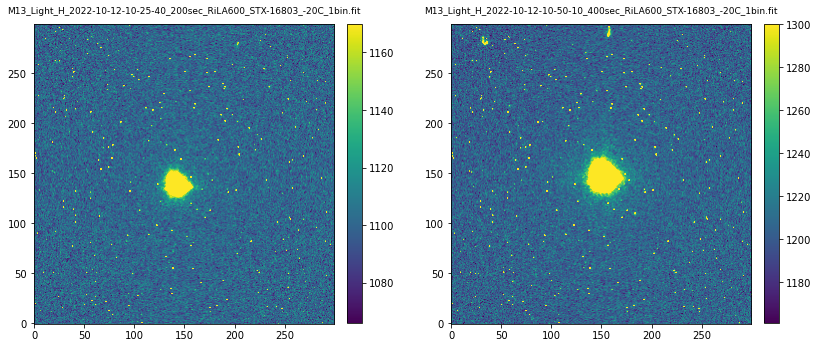

In [ ]:
from astropy.io import fits
fpath1 = Path(light_fits[0])
fpath2 = Path(light_fits[5])
fpath3 = Path(light_fits[0])
fpath4 = Path(light_fits[3])
hdul1 = fits.open(str(fpath1))
hdul2 = fits.open(str(fpath2))
hdul3 = fits.open(str(fpath3))
hdul4 = fits.open(str(fpath4))

from astropy.nddata import Cutout2D
#2. Loading and Cut Data
cutsizes = 300
cut_coord = [1240, 3150]
#cut_coord = [3247, 1166]
cut_hdu1 = Cutout2D(
                data = hdul1[0].data, 
                position = (cut_coord[0], cut_coord[1]), 
                size=(cutsizes, cutsizes) #cut ccd
                )
cut_hdu2 = Cutout2D(
                data = hdul2[0].data, 
                position = (cut_coord[0], cut_coord[1]), 
                size=(cutsizes, cutsizes) #cut ccd
                )
cut_hdu3 = Cutout2D(
                data = hdul3[0].data, 
                position = (cut_coord[0], cut_coord[1]), 
                size=(cutsizes, cutsizes) #cut ccd
                )
cut_hdu4 = Cutout2D(
                data = hdul4[0].data, 
                position = (cut_coord[0], cut_coord[1]), 
                size=(cutsizes, cutsizes) #cut ccd
                )
print("cut_hdu1", cut_hdu1)

fig, axs = plt.subplots(1, 2, figsize=(12, 12), sharex=False, sharey=False, gridspec_kw=None)

im1 = yvu.zimshow(axs[0], cut_hdu1.data,
                origin="lower")
im2 = yvu.zimshow(axs[1], cut_hdu2.data,
                origin="lower")
# im3 = yvu.zimshow(axs[2], cut_hdu3.data,
#                 origin="lower")
# im4 = yvu.zimshow(axs[3], cut_hdu4.data,
#                 origin="lower")

axs[0].set_title('The result of combine master bias image using 20 images')
axs[1].set_title('The histrogram of pixel value')
plt.colorbar(im1, 
        ax=axs[0],
        fraction=0.0455, pad=0.04)
plt.colorbar(im2, 
        ax=axs[1],
        fraction=0.0455, pad=0.04)
axs[0].set_title(f"{str(fpath1.name)}", pad=10, fontsize=9)
axs[1].set_title(f"{str(fpath2.name)}", pad=10, fontsize=9)

# plt.annotate(f"Min value: {hdul_bias[0].data.min()}, \
#         Mean value: {hdul_bias[0].data.mean():.02f}, \
#         Mean value: {hdul_bias[0].data.max()}",
#         fontsize=10, xy=(0, 0), xytext=(3, -30), va='top', ha='left',
#         xycoords='axes fraction', textcoords='offset points')

plt.tight_layout(pad=3.0)

cut_hdu1 <astropy.nddata.utils.Cutout2D object at 0x00000294D916FBE0>


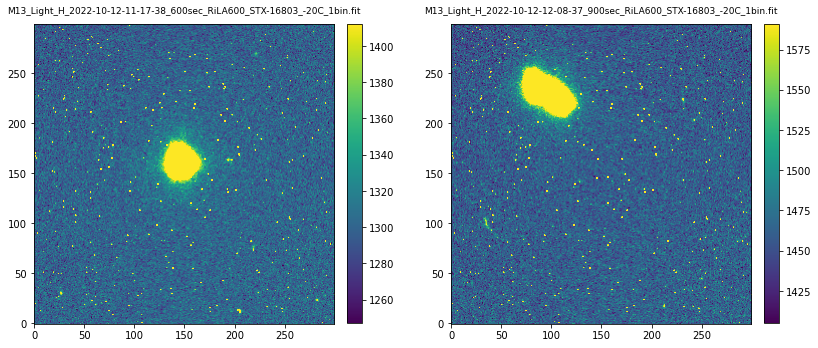

In [ ]:
from astropy.io import fits
fpath1 = Path(light_fits[10])
fpath2 = Path(light_fits[15])
fpath3 = Path(light_fits[0])
fpath4 = Path(light_fits[3])
hdul1 = fits.open(str(fpath1))
hdul2 = fits.open(str(fpath2))
hdul3 = fits.open(str(fpath3))
hdul4 = fits.open(str(fpath4))

from astropy.nddata import Cutout2D
#2. Loading and Cut Data
cutsizes = 300
cut_coord = [1240, 3150]
#cut_coord = [3247, 1166]
cut_hdu1 = Cutout2D(
                data = hdul1[0].data, 
                position = (cut_coord[0], cut_coord[1]), 
                size=(cutsizes, cutsizes) #cut ccd
                )
cut_hdu2 = Cutout2D(
                data = hdul2[0].data, 
                position = (cut_coord[0], cut_coord[1]), 
                size=(cutsizes, cutsizes) #cut ccd
                )
cut_hdu3 = Cutout2D(
                data = hdul3[0].data, 
                position = (cut_coord[0], cut_coord[1]), 
                size=(cutsizes, cutsizes) #cut ccd
                )
cut_hdu4 = Cutout2D(
                data = hdul4[0].data, 
                position = (cut_coord[0], cut_coord[1]), 
                size=(cutsizes, cutsizes) #cut ccd
                )
print("cut_hdu1", cut_hdu1)

fig, axs = plt.subplots(1, 2, figsize=(12, 12), sharex=False, sharey=False, gridspec_kw=None)

im1 = yvu.zimshow(axs[0], cut_hdu1.data,
                origin="lower")
im2 = yvu.zimshow(axs[1], cut_hdu2.data,
                origin="lower")
# im3 = yvu.zimshow(axs[2], cut_hdu3.data,
#                 origin="lower")
# im4 = yvu.zimshow(axs[3], cut_hdu4.data,
#                 origin="lower")

axs[0].set_title('The result of combine master bias image using 20 images')
axs[1].set_title('The histrogram of pixel value')
plt.colorbar(im1, 
        ax=axs[0],
        fraction=0.0455, pad=0.04)
plt.colorbar(im2, 
        ax=axs[1],
        fraction=0.0455, pad=0.04)
axs[0].set_title(f"{str(fpath1.name)}", pad=10, fontsize=9)
axs[1].set_title(f"{str(fpath2.name)}", pad=10, fontsize=9)

# plt.annotate(f"Min value: {hdul_bias[0].data.min()}, \
#         Mean value: {hdul_bias[0].data.mean():.02f}, \
#         Mean value: {hdul_bias[0].data.max()}",
#         fontsize=10, xy=(0, 0), xytext=(3, -30), va='top', ha='left',
#         xycoords='axes fraction', textcoords='offset points')

plt.tight_layout(pad=3.0)

In [ ]:
#n = 0

for fpath_str in light_fits:
    fpath = Path(fpath_str)
    print("type(fpath)", type(fpath))
    print("fpath", fpath)

## guide test2

In [ ]:
BASEDIR = Path(BASEDIRs[8])
print ("Starting...\n{}".format(BASEDIR))

BASEDIR = Path(BASEDIR)

MASTERDIR = BASEDIR / astro_utilities.master_dir
SOLVEDDIR = BASEDIR / astro_utilities.solved_dir

summary = yfu.make_summary(BASEDIR/"*.fit*")
#summary = yfu.make_summary(SOLVEDDIR/"*.fit*")
#print(summary)
#print("len(summary):", len(summary))
#print("summary:", summary)
#print(summary["file"][0])

df_light = summary.loc[summary["IMAGETYP"] == "LIGHT"].copy()
df_light = df_light.reset_index(drop=True)
#print("df_light:\n{}".format(df_light))

light_fits = df_light["file"]
print(type(light_fits))
print(len(light_fits))
print(light_fits)


Starting...
R:\CCD_obs\RiLA600_2022\M27_Light_-_2022-10-12_-_RiLA600_STX-16803_-_1bin
All 46 keywords (guessed from R:\CCD_obs\RiLA600_2022\M27_Light_-_2022-10-12_-_RiLA600_STX-16803_-_1bin\M27_Light_H_2022-10-12-10-01-04_200sec_RiLA600_STX-16803_-20C_1bin.fit) will be loaded.
<class 'pandas.core.series.Series'>
14
0     R:\CCD_obs\RiLA600_2022\M27_Light_-_2022-10-12...
1     R:\CCD_obs\RiLA600_2022\M27_Light_-_2022-10-12...
2     R:\CCD_obs\RiLA600_2022\M27_Light_-_2022-10-12...
3     R:\CCD_obs\RiLA600_2022\M27_Light_-_2022-10-12...
4     R:\CCD_obs\RiLA600_2022\M27_Light_-_2022-10-12...
5     R:\CCD_obs\RiLA600_2022\M27_Light_-_2022-10-12...
6     R:\CCD_obs\RiLA600_2022\M27_Light_-_2022-10-12...
7     R:\CCD_obs\RiLA600_2022\M27_Light_-_2022-10-12...
8     R:\CCD_obs\RiLA600_2022\M27_Light_-_2022-10-12...
9     R:\CCD_obs\RiLA600_2022\M27_Light_-_2022-10-12...
10    R:\CCD_obs\RiLA600_2022\M27_Light_-_2022-10-12...
11    R:\CCD_obs\RiLA600_2022\M27_Light_-_2022-10-12...
12    R:\CC

cut_hdu1 <astropy.nddata.utils.Cutout2D object at 0x00000294CC577220>


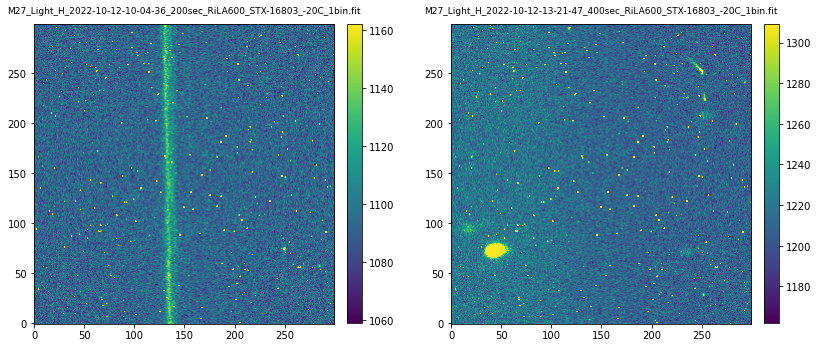

In [ ]:
from astropy.io import fits
fpath1 = Path(light_fits[1])
fpath2 = Path(light_fits[5])
fpath3 = Path(light_fits[0])
fpath4 = Path(light_fits[3])
hdul1 = fits.open(str(fpath1))
hdul2 = fits.open(str(fpath2))
hdul3 = fits.open(str(fpath3))
hdul4 = fits.open(str(fpath4))

from astropy.nddata import Cutout2D
#2. Loading and Cut Datacutsizes = 300
cutsizes = 300
cut_coord = [1486, 2704]
#cut_coord = [3247, 1166]
cut_hdu1 = Cutout2D(
                data = hdul1[0].data, 
                position = (cut_coord[0], cut_coord[1]), 
                size=(cutsizes, cutsizes) #cut ccd
                )
cut_hdu2 = Cutout2D(
                data = hdul2[0].data, 
                position = (cut_coord[0], cut_coord[1]), 
                size=(cutsizes, cutsizes) #cut ccd
                )
cut_hdu3 = Cutout2D(
                data = hdul3[0].data, 
                position = (cut_coord[0], cut_coord[1]), 
                size=(cutsizes, cutsizes) #cut ccd
                )
cut_hdu4 = Cutout2D(
                data = hdul4[0].data, 
                position = (cut_coord[0], cut_coord[1]), 
                size=(cutsizes, cutsizes) #cut ccd
                )
print("cut_hdu1", cut_hdu1)

fig, axs = plt.subplots(1, 2, figsize=(12, 12), sharex=False, sharey=False, gridspec_kw=None)

im1 = yvu.zimshow(axs[0], cut_hdu1.data,
                origin="lower")
im2 = yvu.zimshow(axs[1], cut_hdu2.data,
                origin="lower")
# im3 = yvu.zimshow(axs[2], cut_hdu3.data,
#                 origin="lower")
# im4 = yvu.zimshow(axs[3], cut_hdu4.data,
#                 origin="lower")

axs[0].set_title('The result of combine master bias image using 20 images')
axs[1].set_title('The histrogram of pixel value')
plt.colorbar(im1, 
        ax=axs[0],
        fraction=0.0455, pad=0.04)
plt.colorbar(im2, 
        ax=axs[1],
        fraction=0.0455, pad=0.04)
axs[0].set_title(f"{str(fpath1.name)}", pad=10, fontsize=9)
axs[1].set_title(f"{str(fpath2.name)}", pad=10, fontsize=9)

# plt.annotate(f"Min value: {hdul_bias[0].data.min()}, \
#         Mean value: {hdul_bias[0].data.mean():.02f}, \
#         Mean value: {hdul_bias[0].data.max()}",
#         fontsize=10, xy=(0, 0), xytext=(3, -30), va='top', ha='left',
#         xycoords='axes fraction', textcoords='offset points')

plt.tight_layout(pad=3.0)

cut_hdu1 <astropy.nddata.utils.Cutout2D object at 0x00000294CC55FF70>


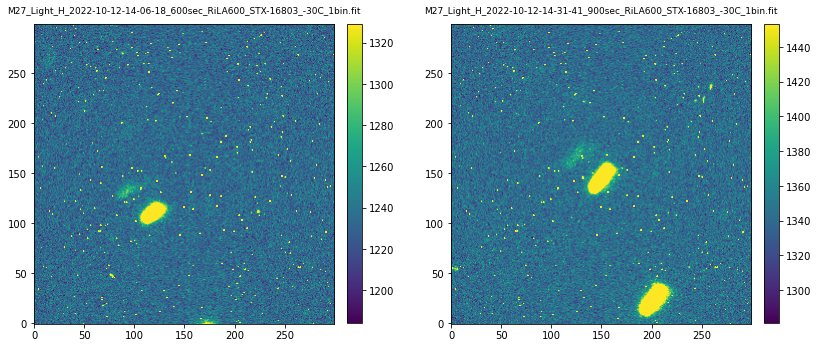

In [ ]:
from astropy.io import fits
fpath1 = Path(light_fits[11])
fpath2 = Path(light_fits[13])
fpath3 = Path(light_fits[0])
fpath4 = Path(light_fits[3])
hdul1 = fits.open(str(fpath1))
hdul2 = fits.open(str(fpath2))
hdul3 = fits.open(str(fpath3))
hdul4 = fits.open(str(fpath4))

from astropy.nddata import Cutout2D
#2. Loading and Cut Datacutsizes = 300
cutsizes = 300
cut_coord = [1486, 2704]
#cut_coord = [3247, 1166]
cut_hdu1 = Cutout2D(
                data = hdul1[0].data, 
                position = (cut_coord[0], cut_coord[1]), 
                size=(cutsizes, cutsizes) #cut ccd
                )
cut_hdu2 = Cutout2D(
                data = hdul2[0].data, 
                position = (cut_coord[0], cut_coord[1]), 
                size=(cutsizes, cutsizes) #cut ccd
                )
cut_hdu3 = Cutout2D(
                data = hdul3[0].data, 
                position = (cut_coord[0], cut_coord[1]), 
                size=(cutsizes, cutsizes) #cut ccd
                )
cut_hdu4 = Cutout2D(
                data = hdul4[0].data, 
                position = (cut_coord[0], cut_coord[1]), 
                size=(cutsizes, cutsizes) #cut ccd
                )
print("cut_hdu1", cut_hdu1)

fig, axs = plt.subplots(1, 2, figsize=(12, 12), sharex=False, sharey=False, gridspec_kw=None)

im1 = yvu.zimshow(axs[0], cut_hdu1.data,
                origin="lower")
im2 = yvu.zimshow(axs[1], cut_hdu2.data,
                origin="lower")
# im3 = yvu.zimshow(axs[2], cut_hdu3.data,
#                 origin="lower")
# im4 = yvu.zimshow(axs[3], cut_hdu4.data,
#                 origin="lower")

axs[0].set_title('The result of combine master bias image using 20 images')
axs[1].set_title('The histrogram of pixel value')
plt.colorbar(im1, 
        ax=axs[0],
        fraction=0.0455, pad=0.04)
plt.colorbar(im2, 
        ax=axs[1],
        fraction=0.0455, pad=0.04)
axs[0].set_title(f"{str(fpath1.name)}", pad=10, fontsize=9)
axs[1].set_title(f"{str(fpath2.name)}", pad=10, fontsize=9)

# plt.annotate(f"Min value: {hdul_bias[0].data.min()}, \
#         Mean value: {hdul_bias[0].data.mean():.02f}, \
#         Mean value: {hdul_bias[0].data.max()}",
#         fontsize=10, xy=(0, 0), xytext=(3, -30), va='top', ha='left',
#         xycoords='axes fraction', textcoords='offset points')

plt.tight_layout(pad=3.0)

## guide test3

In [ ]:
BASEDIR = Path(BASEDIRs[12])
print ("Starting...\n{}".format(BASEDIR))

BASEDIR = Path(BASEDIR)

MASTERDIR = BASEDIR / astro_utilities.master_dir
SOLVEDDIR = BASEDIR / astro_utilities.solved_dir

summary = yfu.make_summary(BASEDIR/"*.fit*")
#summary = yfu.make_summary(SOLVEDDIR/"*.fit*")
#print(summary)
#print("len(summary):", len(summary))
#print("summary:", summary)
#print(summary["file"][0])

df_light = summary.loc[summary["IMAGETYP"] == "LIGHT"].copy()
df_light = df_light.reset_index(drop=True)
#print("df_light:\n{}".format(df_light))

light_fits = df_light["file"]
print(type(light_fits))
print(len(light_fits))
print(light_fits)

Starting...
R:\CCD_obs\RiLA600_2022\M36_Light_-_2022-10-12_-_RiLA600_STX-16803_-_1bin
All 46 keywords (guessed from R:\CCD_obs\RiLA600_2022\M36_Light_-_2022-10-12_-_RiLA600_STX-16803_-_1bin\M36_Light_H_2022-10-12-17-49-48_200sec_RiLA600_STX-16803_-30C_1bin.fit) will be loaded.
<class 'pandas.core.series.Series'>
12
0     R:\CCD_obs\RiLA600_2022\M36_Light_-_2022-10-12...
1     R:\CCD_obs\RiLA600_2022\M36_Light_-_2022-10-12...
2     R:\CCD_obs\RiLA600_2022\M36_Light_-_2022-10-12...
3     R:\CCD_obs\RiLA600_2022\M36_Light_-_2022-10-12...
4     R:\CCD_obs\RiLA600_2022\M36_Light_-_2022-10-12...
5     R:\CCD_obs\RiLA600_2022\M36_Light_-_2022-10-12...
6     R:\CCD_obs\RiLA600_2022\M36_Light_-_2022-10-12...
7     R:\CCD_obs\RiLA600_2022\M36_Light_-_2022-10-12...
8     R:\CCD_obs\RiLA600_2022\M36_Light_-_2022-10-12...
9     R:\CCD_obs\RiLA600_2022\M36_Light_-_2022-10-12...
10    R:\CCD_obs\RiLA600_2022\M36_Light_-_2022-10-12...
11    R:\CCD_obs\RiLA600_2022\M36_Light_-_2022-10-12...
Name: file,

cut_hdu1 <astropy.nddata.utils.Cutout2D object at 0x00000294D57440D0>


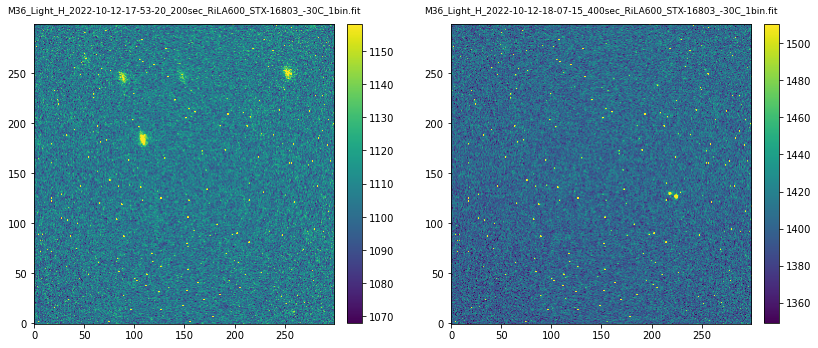

In [ ]:
from astropy.io import fits
fpath1 = Path(light_fits[1])
fpath2 = Path(light_fits[4])
fpath3 = Path(light_fits[0])
fpath4 = Path(light_fits[3])
hdul1 = fits.open(str(fpath1))
hdul2 = fits.open(str(fpath2))
hdul3 = fits.open(str(fpath3))
hdul4 = fits.open(str(fpath4))

from astropy.nddata import Cutout2D
#2. Loading and Cut Data
cutsizes = 300
cut_coord = [1300, 1400]
#cut_coord = [3247, 1166]
cut_hdu1 = Cutout2D(
                data = hdul1[0].data, 
                position = (cut_coord[0], cut_coord[1]), 
                size=(cutsizes, cutsizes) #cut ccd
                )
cut_hdu2 = Cutout2D(
                data = hdul2[0].data, 
                position = (cut_coord[0], cut_coord[1]), 
                size=(cutsizes, cutsizes) #cut ccd
                )
cut_hdu3 = Cutout2D(
                data = hdul3[0].data, 
                position = (cut_coord[0], cut_coord[1]), 
                size=(cutsizes, cutsizes) #cut ccd
                )
cut_hdu4 = Cutout2D(
                data = hdul4[0].data, 
                position = (cut_coord[0], cut_coord[1]), 
                size=(cutsizes, cutsizes) #cut ccd
                )
print("cut_hdu1", cut_hdu1)

fig, axs = plt.subplots(1, 2, figsize=(12, 12), sharex=False, sharey=False, gridspec_kw=None)

im1 = yvu.zimshow(axs[0], cut_hdu1.data,
                origin="lower")
im2 = yvu.zimshow(axs[1], cut_hdu2.data,
                origin="lower")
# im3 = yvu.zimshow(axs[2], cut_hdu3.data,
#                 origin="lower")
# im4 = yvu.zimshow(axs[3], cut_hdu4.data,
#                 origin="lower")

axs[0].set_title('The result of combine master bias image using 20 images')
axs[1].set_title('The histrogram of pixel value')
plt.colorbar(im1, 
        ax=axs[0],
        fraction=0.0455, pad=0.04)
plt.colorbar(im2, 
        ax=axs[1],
        fraction=0.0455, pad=0.04)
axs[0].set_title(f"{str(fpath1.name)}", pad=10, fontsize=9)
axs[1].set_title(f"{str(fpath2.name)}", pad=10, fontsize=9)

# plt.annotate(f"Min value: {hdul_bias[0].data.min()}, \
#         Mean value: {hdul_bias[0].data.mean():.02f}, \
#         Mean value: {hdul_bias[0].data.max()}",
#         fontsize=10, xy=(0, 0), xytext=(3, -30), va='top', ha='left',
#         xycoords='axes fraction', textcoords='offset points')

plt.tight_layout(pad=3.0)

cut_hdu1 <astropy.nddata.utils.Cutout2D object at 0x00000294CC5C9430>


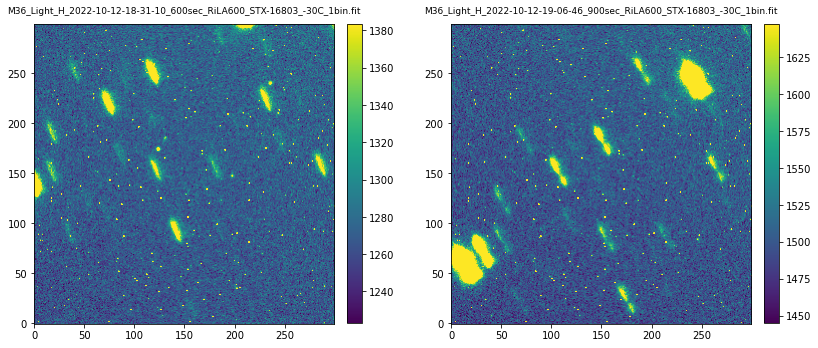

In [ ]:
from astropy.io import fits
fpath1 = Path(light_fits[7])
fpath2 = Path(light_fits[10])
fpath3 = Path(light_fits[0])
fpath4 = Path(light_fits[3])
hdul1 = fits.open(str(fpath1))
hdul2 = fits.open(str(fpath2))
hdul3 = fits.open(str(fpath3))
hdul4 = fits.open(str(fpath4))

from astropy.nddata import Cutout2D
#2. Loading and Cut Data
cutsizes = 300

#cut_coord = [3247, 1166]
cut_hdu1 = Cutout2D(
                data = hdul1[0].data, 
                position = (cut_coord[0], cut_coord[1]), 
                size=(cutsizes, cutsizes) #cut ccd
                )
cut_hdu2 = Cutout2D(
                data = hdul2[0].data, 
                position = (cut_coord[0], cut_coord[1]), 
                size=(cutsizes, cutsizes) #cut ccd
                )
cut_hdu3 = Cutout2D(
                data = hdul3[0].data, 
                position = (cut_coord[0], cut_coord[1]), 
                size=(cutsizes, cutsizes) #cut ccd
                )
cut_hdu4 = Cutout2D(
                data = hdul4[0].data, 
                position = (cut_coord[0], cut_coord[1]), 
                size=(cutsizes, cutsizes) #cut ccd
                )
print("cut_hdu1", cut_hdu1)

fig, axs = plt.subplots(1, 2, figsize=(12, 12), sharex=False, sharey=False, gridspec_kw=None)

im1 = yvu.zimshow(axs[0], cut_hdu1.data,
                origin="lower")
im2 = yvu.zimshow(axs[1], cut_hdu2.data,
                origin="lower")
# im3 = yvu.zimshow(axs[2], cut_hdu3.data,
#                 origin="lower")
# im4 = yvu.zimshow(axs[3], cut_hdu4.data,
#                 origin="lower")

axs[0].set_title('The result of combine master bias image using 20 images')
axs[1].set_title('The histrogram of pixel value')
plt.colorbar(im1, 
        ax=axs[0],
        fraction=0.0455, pad=0.04)
plt.colorbar(im2, 
        ax=axs[1],
        fraction=0.0455, pad=0.04)
axs[0].set_title(f"{str(fpath1.name)}", pad=10, fontsize=9)
axs[1].set_title(f"{str(fpath2.name)}", pad=10, fontsize=9)

# plt.annotate(f"Min value: {hdul_bias[0].data.min()}, \
#         Mean value: {hdul_bias[0].data.mean():.02f}, \
#         Mean value: {hdul_bias[0].data.max()}",
#         fontsize=10, xy=(0, 0), xytext=(3, -30), va='top', ha='left',
#         xycoords='axes fraction', textcoords='offset points')

plt.tight_layout(pad=3.0)